# 3. Model Analysis

This notebook analyzes model predictions and investigates individual creatures.

**Input:**
- `helper_files/engineered_features.parquet`
- `pickled_models/hp_model_cr*.pkl`

**Output:**
- `data/engineered_features.csv`
- `data/feature_contributions.csv`

## Imports and Configs

In [11]:
import numpy as np
import os
import pandas as pd
import sys

from pathlib import Path

In [12]:
# Detect execution context and set paths dynamically
sys.path.insert(0, '.')

# Get the current working directory
cwd = Path.cwd()

# Check if we're in the notebooks directory or project root
if cwd.name == 'notebooks':
    # Running from notebooks directory (in Jupyter)
    DATA_DIR = '../data'
    PICKLED_MODELS_DIR = '../pickled_models'
    MONSTER_BUILDER_DIR = '../monster-builder-v2'
    HELPERS_DIR = './helper_files'
    IO_DIR = './notebooks_io'
    IN_NB_DIR = False
else:
    # Running from project root (via run_three_tier_model.py)
    DATA_DIR = './data'
    PICKLED_MODELS_DIR = './pickled_models'
    MONSTER_BUILDER_DIR = './monster-builder-v2'
    HELPERS_DIR = './notebooks/helper_files'
    IO_DIR = './notebooks/notebooks_io'
    IN_NB_DIR = False

print(f"📁 Execution context detected:")
print(f"   Current directory: {cwd}")
print(f"   Data directory: {DATA_DIR}")
print(f"   Models directory: {PICKLED_MODELS_DIR}")

print("Imports successful")

📁 Execution context detected:
   Current directory: /workspaces/matrix_v0
   Data directory: ./data
   Models directory: ./pickled_models
Imports successful


In [13]:
# Add helper_files to path
if IN_NB_DIR is True:
    from helper_files import (
        load_model, get_phase3_features, investigate_creature, summarize_model_performance,
        analyze_predictions_by_cr,
        plot_performance_scatter, plot_error_hist,
        CR_TIERS, feature_importance_by_tier
    )

    print("Imports successful")
else:
    from notebooks.helper_files import (
        load_model, get_phase3_features, investigate_creature, summarize_model_performance,
        analyze_predictions_by_cr,
        plot_performance_scatter, plot_error_hist,
        CR_TIERS, feature_importance_by_tier
    )

    print("Imports successful")


Imports successful


## Load Data and Models

In [14]:
import_path = DATA_DIR + '/engineered_features.csv'
df = pd.read_csv(import_path)
df['has_feature_mods'] = df[[c for c in df.columns if 'feature_' in c]].sum(axis=1) > 0

In [15]:
import_path = DATA_DIR + '/feature_contributions.csv'
contributions_df = pd.read_csv(import_path)

In [16]:
phase3_features = get_phase3_features()

In [17]:
results = {}
load_path = PICKLED_MODELS_DIR + "/hp_model_tier.pkl"
# Save each model
for tier in ['cr1', 'cr2', 'cr3', 'cr4', 'cr5']:

    filepath = load_path.replace('tier', tier)
    results[tier] = load_model(filepath)
    print(f"Loaded {tier} model to {filepath}")

print("\nAll models loaded successfully!")

Loaded cr1 model to ./pickled_models/hp_model_cr1.pkl
Loaded cr2 model to ./pickled_models/hp_model_cr2.pkl
Loaded cr3 model to ./pickled_models/hp_model_cr3.pkl
Loaded cr4 model to ./pickled_models/hp_model_cr4.pkl
Loaded cr5 model to ./pickled_models/hp_model_cr5.pkl

All models loaded successfully!


In [18]:
results['cr1'].keys()


dict_keys(['model', 'scaler', 'feature_names', 'train_count', 'test_r2', 'test_mae'])

## Model Analysis

In [19]:
summarize_model_performance(results)


5-BUCKET HP MODEL TRAINING COMPLETE

MODEL PERFORMANCE SUMMARY:

   CR < 1 Model:
      Training samples: 113
      Test R²:  0.3642
      Test MAE: 5.18 HP

   CR 1-4 Model:
      Training samples: 99
      Test R²:  0.3690
      Test MAE: 13.31 HP

   CR 5-10 Model:
      Training samples: 65
      Test R²:  0.1648
      Test MAE: 23.13 HP

   CR 11-16 Model:
      Training samples: 27
      Test R²:  0.8643
      Test MAE: 9.61 HP

   CR > 16 Model:
      Training samples: 20
      Test R²:  0.5966
      Test MAE: 67.99 HP

All 5 models trained successfully!


In [20]:
# Display top feature coefficients for each tier
for tier in ['cr1', 'cr2', 'cr3', 'cr4', 'cr5']:
    print(f"\n{tier.upper()} Top Features by Coefficient:")
    coefs = results[tier]['model'].coef_
    feat_names = results[tier]['feature_names']
    coef_df = pd.DataFrame({
        'feature': feat_names,
        'coefficient': coefs
    }).sort_values('coefficient', key=abs, ascending=False)
    coef_df['coefficient'] = coef_df['coefficient'].apply(lambda x: '{:,.0f}'.format(x))
    
    print(coef_df.head(10).to_string(index=False))


CR1 Top Features by Coefficient:
                    feature coefficient
         inflicts_petrified          -1
         inflicts_paralyzed          -1
           inflicts_blinded          -1
     size_ordinal_deviation           1
           has_spellcasting          -0
        inflicts_frightened          -0
        vulnerability_count           0
    has_regeneration_scaled           0
     legendary_action_count           0
legendary_actions_per_round           0

CR2 Top Features by Coefficient:
                        feature coefficient
               inflicts_charmed          -6
            vulnerability_count           3
             inflicts_petrified          -3
             inflicts_paralyzed          -3
         inflicts_incapacitated          -1
         size_ordinal_deviation           1
              inflicts_poisoned          -0
    legendary_actions_per_round          -0
         legendary_action_count          -0
has_legendary_resistance_scaled           0

CR3 Top

## Investigate Specific Creatures

In [21]:
# [c for c in df.columns if 'hp' in c]

In [22]:
df[(df.has_flying==1) & (df.cr_numeric >= 5) & (df.cr_numeric <= 10)].sort_values('predicted_hp')[['Name', 'cr_numeric', 'actual_hp', 'predicted_hp', 'hp_delta_pct']]

,Name,cr_numeric,actual_hp,predicted_hp,hp_delta_pct
241,Mage,6.0,40,53.304147,33.260367
239,Young White Dragon,6.0,133,69.425000,-47.800752
240,Young Brass Dragon,6.0,110,78.612500,-28.534091
233,Air Elemental,5.0,90,88.859375,-1.267361
248,Young Black Dragon,7.0,127,90.625000,-28.641732
256,Young Bronze Dragon,8.0,142,91.337500,-35.677817
224,Wraith,5.0,67,97.382262,45.346660
270,Young Silver Dragon,9.0,168,98.937500,-41.108631
242,Vrock,6.0,104,101.004625,-2.880168
252,Young Copper Dragon,7.0,119,101.687500,-14.548319


In [38]:
# Interactive investigation
# Uncomment and modify to investigate specific creatures:
# Oni, Unicorn way too penalized for different reasons.
investigate_creature('Young Green Dragon', df, contributions_df)

  YOUNG GREEN DRAGON (CR 8.0)

Actual HP:             136
Predicted HP:          104
Error:                 -32  ( -23.2%)

--------------------------------------------------------------------------------

PHASE 1: CR BASELINE
  HP Baseline (CR 8.0):                               163
  HP after Phase 1:                                     163

PHASE 2: COMBAT STATS

  Deviation Breakdown:
    Stat         Estimated   Feature    Total  Baseline  Deviation
    ------------------------------------------------------------
    AC                  18        +4       22        15         +7
    Attack               7        +0        7         7         +0
    DPR                 44       +13       57        53         +4
    Save DC             14        --       14        15         -1

  Costed DMG Features:
    feature_ac (+4):  saving_throws (4 saves) +2, flying (CR 8) +2
    feature_attack (+0):  (none)
    feature_dpr (+13):  (none)
    feature_hp (+0):  (none)

  HP Penalties:
    ac_

In [24]:
df[df['Name']=='Cloaker'][[c for c in df.columns if 'dpr' in c]]

,dpr_baseline,estimated_dpr,feature_dpr,legendary_dpr,total_dpr,dpr_deviation
262,53.0,17.5,0.0,0,17.5,-35.5


In [25]:
# _df = analysis_dfs['cr3']
# _df.sort_values('predicted_hp')

In [26]:
# List worst predictions
# print("\nWorst Over-predictions (predicted > actual):")
# over_pred = df[df['hp_delta'] > 0].nlargest(10, 'hp_delta_pct')[['Name', 'cr_numeric', 'actual_hp', 'predicted_hp', 'hp_delta_pct']]
# print(over_pred.to_string(index=False))

# print("\nWorst Under-predictions (predicted < actual):")
# under_pred = df[df['hp_delta'] < 0].nsmallest(10, 'hp_delta_pct')[['Name', 'cr_numeric', 'actual_hp', 'predicted_hp', 'hp_delta_pct']]
# print(under_pred.to_string(index=False))

# print("\nBest Predictions:")
# df_check_best = df[['Name', 'cr_numeric', 'actual_hp', 'predicted_hp', 'hp_delta_pct']].copy()
# df_check_best['hp_delta_pct_abs'] = df_check_best['hp_delta_pct'].abs()
# best = df_check_best.nsmallest(10, 'hp_delta_pct_abs')
# print(best.to_string(index=False))

# Deatiled Model Breakdown

In [27]:
analysis_dfs = analyze_predictions_by_cr(df)



CR < 1 - Best 10 Predictions:
        Name    CR  Actual_HP  Predicted_HP     Error
     Cultist 0.125          9      8.999991  0.000009
  Cockatrice 0.500         27     27.000018 -0.000018
      Stirge 0.125          2      2.018213 -0.018213
    Commoner 0.000          4      4.125000 -0.125000
         Owl 0.000          1      0.643213  0.356787
Magma Mephit 0.500         22     21.530227  0.469773
  Darkmantle 0.500         22     22.526332 -0.526332
   Giant Rat 0.125          7      6.321607  0.678393
  Blood Hawk 0.125          7      6.321607  0.678393
    Warhorse 0.500         19     18.303393  0.696607

CR < 1 - Worst 10 Predictions:
                 Name   CR  Actual_HP  Predicted_HP      Error
Giant Poisonous Snake 0.25         11      0.000000  11.000000
                 Drow 0.25         13      1.663932  11.336068
           Giant Wasp 0.50         13     24.575848 -11.575848
            Hobgoblin 0.50         11     22.625000 -11.625000
                Scout 0.50  

In [28]:
_df_check = analysis_dfs['cr2']
[c for c in _df_check.columns if 'immun' in c]


['hp_after_resist_immun_penalty',
 'immunity_count',
 'feature_spell_immunity',
 'feature_turn_immunity']

In [29]:
# _df_check = analysis_dfs['cr2']
# _df_check[_df_check['actual_hp'] == 45]



📊 VISUALIZATION: Actual vs Predicted HP (5 CR Buckets)


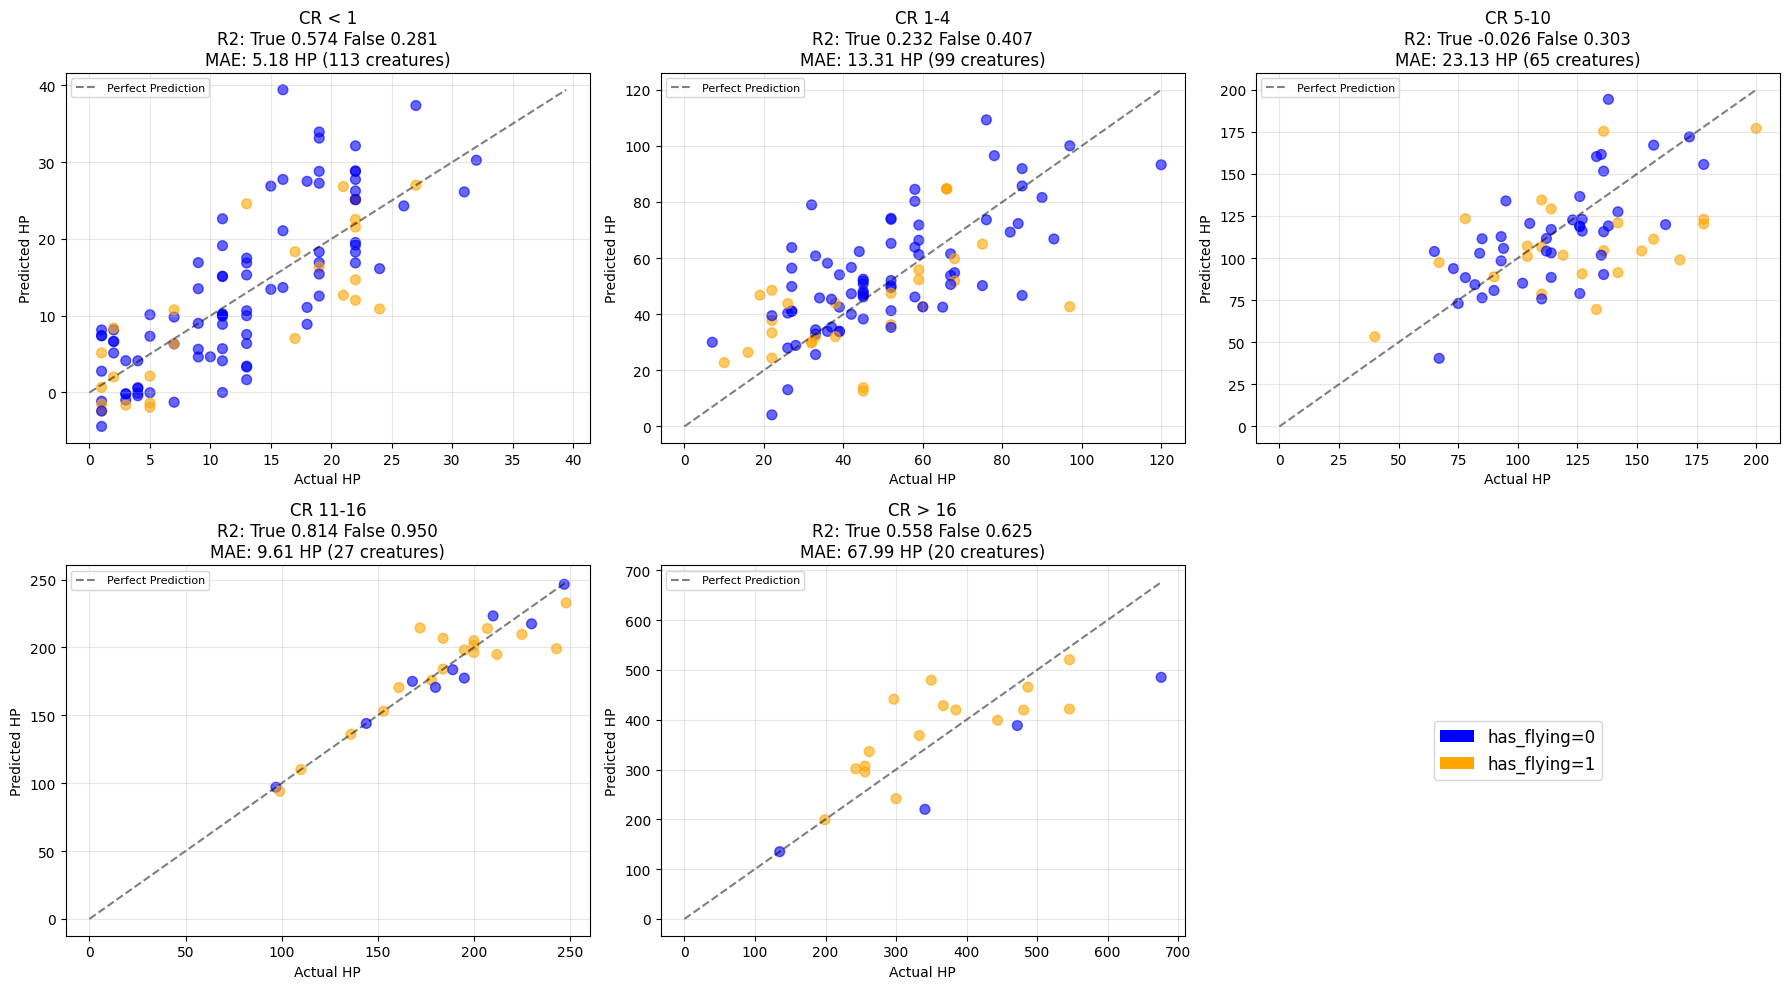

In [30]:

plot_performance_scatter(analysis_dfs, highlight_feature='has_flying')

In [31]:
for k, v in df[df['Name']=='Hill Giant'][[c for c in df.columns if 'feature' in c]].iloc[0].items():
    print(f"{k}: {v}")

feature_dpr: 0.0
feature_ac: 0
feature_attack: 0
feature_hp: 0.0
feature_aggressive: 0
feature_ambusher: 0
feature_amorphous: 0
feature_amphibious: 0
feature_angelic_weapons: 0
feature_antimagic_susceptibility: 0
feature_avoidance: 0
feature_blind_senses: 0
feature_blood_frenzy: 0
feature_breath_weapon: 0
feature_brute: 0
feature_charge: 0
feature_charm: 0
feature_constrict: 0
feature_damage_absorption: 0
feature_damage_transfer: 0
feature_death_burst: 0
feature_devils_sight: 0
feature_dive_attack: 0
feature_echolocation: 0
feature_elemental_body: 0
feature_enlarge: 0
feature_etherealness: 0
feature_false_appearance: 0
feature_fey_ancestry: 0
feature_fiendish_blessing: 0
feature_flyby: 0
feature_frightful_presence: 0
feature_grapple: 0
feature_grappler: 0
feature_hold_breath: 0
feature_horrifying_visage: 0
feature_illumination: 0
feature_immutable_form: 0
feature_incorporeal_movement: 0
feature_innate_spellcasting: 0
feature_invisibility: 0
feature_keen_senses: 0
feature_labyrinthine_r

In [32]:
_df = analysis_dfs['cr3']
_df.sort_values('predicted_hp')

,Name,cr_numeric,actual_hp,predicted_hp,hp_delta,hp_delta_pct,hp_delta_pct_percentile,hp_baseline,ac_baseline,attack_baseline,...,has_attackers_advantage,inflicts_prone,has_grapple,has_feature_mods,Actual_HP,Predicted_HP,CR,Error,Abs_Error,Pct_Error
23,Unicorn,5.0,67,40.431049,-26.568951,-39.655151,89.230769,114.0,15.0,7.0,...,0,1,0,True,67,40.431049,5.0,26.568951,26.568951,39.655151
29,Mage,6.0,40,53.304147,13.304147,33.260367,83.076923,134.4,15.0,7.0,...,0,0,0,True,40,53.304147,6.0,-13.304147,13.304147,-33.260367
27,Young White Dragon,6.0,133,69.425000,-63.575000,-47.800752,96.923077,134.4,15.0,7.0,...,0,0,0,True,133,69.425000,6.0,63.575000,63.575000,47.800752
42,Spirit Naga,8.0,75,72.994801,-2.005199,-2.673598,9.230769,163.2,15.0,7.0,...,0,0,0,True,75,72.994801,8.0,2.005199,2.005199,2.673598
20,Barbed Devil,5.0,110,75.726012,-34.273988,-31.158171,78.461538,114.0,15.0,7.0,...,0,0,0,True,110,75.726012,5.0,34.273988,34.273988,31.158171
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39,Giant Ape,7.0,157,167.086488,10.086488,6.424515,23.076923,156.0,15.0,7.0,...,0,0,0,False,157,167.086488,7.0,-10.086488,10.086488,-6.424515
43,Hydra,8.0,172,171.999767,-0.000233,-0.000135,1.538462,163.2,15.0,7.0,...,0,0,0,True,172,171.999767,8.0,0.000233,0.000233,0.000135
60,Deva,10.0,136,175.319762,39.319762,28.911590,72.307692,186.0,17.0,9.0,...,0,0,0,True,136,175.319762,10.0,-39.319762,39.319762,-28.911590
57,Cloud Giant,9.0,200,177.086488,-22.913512,-11.456756,35.384615,174.0,16.0,8.0,...,0,0,0,True,200,177.086488,9.0,22.913512,22.913512,11.456756



📊 VISUALIZATION: Error Distribution (5 CR Buckets)


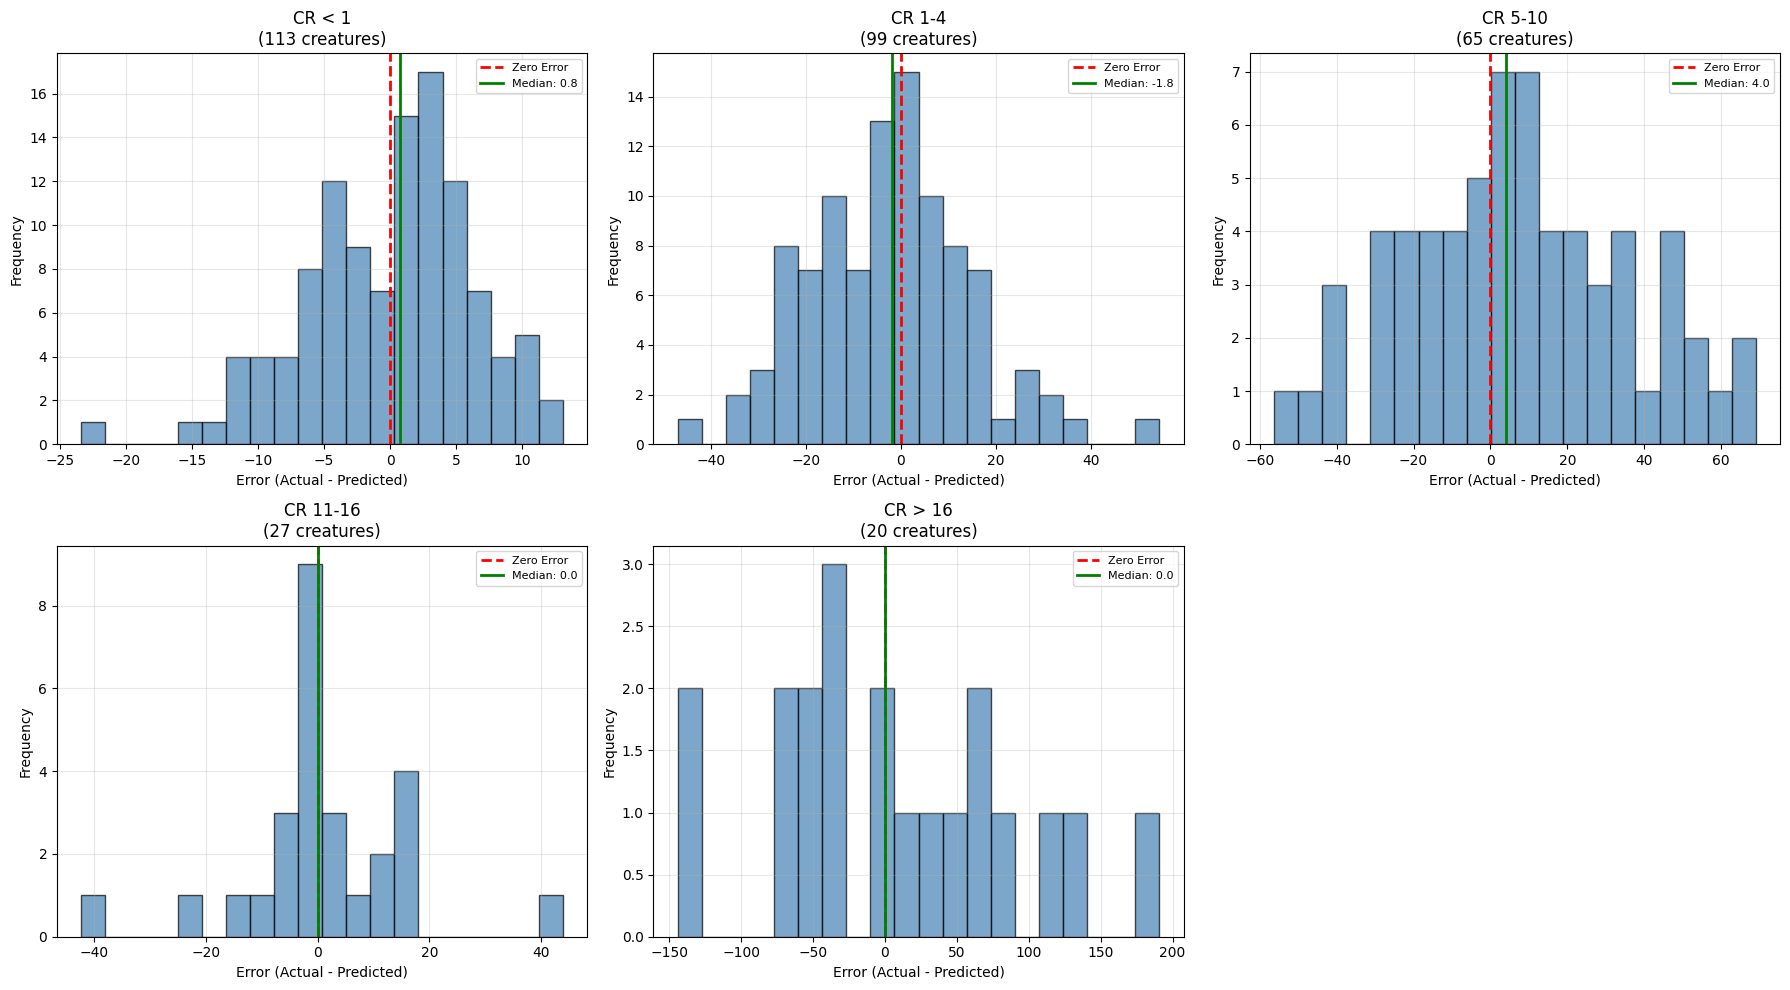

In [33]:
plot_error_hist(analysis_dfs)

# Feature Importance

In [34]:
importance_df = feature_importance_by_tier(contributions_df, df)

FEATURE IMPORTANCE BY CR TIER

  DMG INDIVIDUAL FEATURE COSTS (per-creature HP impact)
  Feature                                 CR < 1     CR 1-4    CR 5-10   CR 11-16    CR > 16
  ------------------------------------------------------------------------------------------
  legendary_resistance                        --         --         --      -90.0     -120.0
    (creature count)                          --         --         --          9         14
  damage_transfer                             --      -27.0      -81.6         --         --
    (creature count)                          --          1          1         --         --
  possession                                  --      -50.4         --         --         --
    (creature count)                          --          1         --         --         --
  blood_frenzy                              -8.0      -12.0      -16.0         --         --
    (creature count)                           2          2          1      

In [35]:
importance_df

,phase,feature,CR < 1,CR 1-4,CR 5-10,CR 11-16,CR > 16
0,DMG Features,legendary_resistance,0.000000,0.000000,0.0,-90.000000,-120.0
1,DMG Features,damage_transfer,0.000000,-27.000000,-81.6,0.000000,0.0
2,DMG Features,possession,0.000000,-50.400000,0.0,0.000000,0.0
3,DMG Features,blood_frenzy,-8.000000,-12.000000,-16.0,0.000000,0.0
4,DMG Features,magic_resistance,-3.000000,-5.000000,-7.0,-9.000000,-12.0
...,...,...,...,...,...,...,...
103,Phase 3,inflicts_poisoned,0.000000,-1.164727,0.0,-15.952336,0.0
104,Phase 3,inflicts_paralyzed,-5.924152,-9.666721,0.0,0.000000,0.0
105,Phase 3,inflicts_blinded,-5.545274,0.000000,0.0,0.000000,0.0
106,Phase 3,has_grapple,0.000000,0.000000,0.0,0.000000,0.0


In [37]:
df['actual_hp'].value_counts().head(10)

actual_hp
22    23
11    12
13    11
1     11
52    10
45    10
19    10
27     7
7      6
2      6
Name: count, dtype: int64